In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_flame/results/target_1.0/fold0_1.0_genomic_windows_table_results.tsv", sep="\t")

fold0["fold"] = [0 for i in range(len(fold0))]
fold0["target"] = [1.0 for i in range(len(fold0))]

In [3]:
fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_flame/results/target_1.0/fold1_1.0_genomic_windows_table_results.tsv", sep="\t")

fold1["fold"] = [1 for i in range(len(fold1))]
fold1["target"] = [1.0 for i in range(len(fold1))]

In [4]:
fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_flame/results/target_1.0/fold2_1.0_genomic_windows_table_results.tsv", sep="\t")

fold2["fold"] = [2 for i in range(len(fold2))]
fold2["target"] = [1.0 for i in range(len(fold2))]

In [5]:
df = pd.concat([fold0, fold1, fold2], ignore_index=True)

In [6]:
df.columns

Index(['chrom', 'fold', 'PearsonR', 'centered_start', 'centered_end',
       'centered_flat_start', 'centered_flat_end', 'active_fraction',
       'neutral_fraction', 'repressive_fraction', 'last_accepted_step', 'SCD',
       'flame_result', 'flame_target', 'flame_init', 'num_edits', 'GC_seq',
       'GC_slice', 'GC_slice_edited', 'init_CTCFs_num', 'CTCFs_num',
       'FIMO_sum', 'FIMO_max', 'orientation', 'positions', 'target'],
      dtype='object')

In [7]:
df["flame_diff"] = df["flame_result"] - df["flame_init"]

In [8]:
alpha_fold0 = pd.read_csv(f"/scratch1/smaruj/alpha_genome_validation/flame_generation/fold0_alphagenome_results.tsv", sep="\t")

alpha_fold0["fold"] = [0 for i in range(len(alpha_fold0))]
alpha_fold0["target"] = [1.0 for i in range(len(alpha_fold0))]

In [9]:
alpha_fold1 = pd.read_csv(f"/scratch1/smaruj/alpha_genome_validation/flame_generation/fold1_alphagenome_results.tsv", sep="\t")

alpha_fold1["fold"] = [1 for i in range(len(alpha_fold1))]
alpha_fold1["target"] = [1.0 for i in range(len(alpha_fold1))]

In [10]:
alpha_fold2 = pd.read_csv(f"/scratch1/smaruj/alpha_genome_validation/flame_generation/fold2_alphagenome_results.tsv", sep="\t")

alpha_fold2["fold"] = [2 for i in range(len(alpha_fold2))]
alpha_fold2["target"] = [1.0 for i in range(len(alpha_fold2))]

In [11]:
alpha_df = pd.concat([alpha_fold0, alpha_fold1, alpha_fold2], ignore_index=True)

In [12]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

Pearson R = 0.9474, p-value = 4.4966e-82


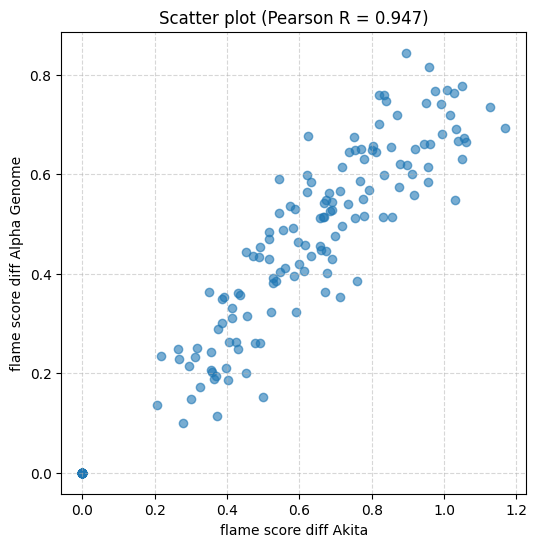

In [13]:
# Assuming df and alpha_df have the same row order
x = df["flame_diff"].values
y = alpha_df["alpha_flame_score_diff"].values

# Calculate Pearson correlation
pearson_r, p_value = pearsonr(x, y)
print(f"Pearson R = {pearson_r:.4f}, p-value = {p_value:.4e}")

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x, y, alpha=0.6)
plt.xlabel("flame score diff Akita")
plt.ylabel("flame score diff Alpha Genome")
plt.title(f"Scatter plot (Pearson R = {pearson_r:.3f})")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()